In [1]:
import os
import sys
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pycocotools.mask as mask_utils
from PIL import Image

# Add root directory to sys path so we can import model_micro
sys.path.append(os.path.abspath('..'))
from model_micro.rti import RTE

In [2]:
dataset_path = "../data/nvidia_warehouse_dataset/train_sample"
with open(os.path.join(dataset_path, "train_sample.json"), "r") as f:
    data = json.load(f)

# Get the first sample and its very first <mask/>
sample = data[0]
rle_mask = sample['rle'][0]

print("Image:", sample['image'])
print("Question:", sample['conversations'][0]['value'])
print("Original Answer:", sample['conversations'][1]['value'])

Image: 054690.png
Question: <image>
Given the available transporters <mask> <mask> and pallets <mask> <mask> <mask> <mask> <mask> <mask> <mask>, which pallet is the best choice for automated pickup by an empty transporter?
Original Answer: The transporter [Region 1] is not transporting any boxes. The pallet [Region 5] is the closest to transporter [Region 1], so it is the most suitable choice for automated picking.


In [3]:
TARGET_W, TARGET_H = 512, 320

img_path = os.path.join(dataset_path, "images", sample['image'])
depth_path = os.path.join(dataset_path, "depths", sample['image'].replace('.png', '_depth.png'))

rgb_image = Image.open(img_path).convert("RGB")
rgb_resized = rgb_image.resize((TARGET_W, TARGET_H), Image.LANCZOS)
rgb_np = np.array(rgb_resized)

depth_pil = Image.open(depth_path)
depth_resized  = depth_pil.resize((TARGET_W, TARGET_H), Image.BILINEAR)
depth_np       = np.array(depth_resized, dtype=np.float32)

# Convert arrays into PyTorch Tensors (Identical to what dataloader does)
rgb_tensor = torch.from_numpy(rgb_np.transpose(2, 0, 1)).float() / 255.0  # [3, H, W]
depth_tensor = torch.from_numpy(np.array(depth_np, dtype=np.float32))       # [H, W]

print("RGB Tensor Shape  :", rgb_tensor.shape)
print("Depth Tensor Shape:", depth_tensor.shape)

RGB Tensor Shape  : torch.Size([3, 320, 512])
Depth Tensor Shape: torch.Size([320, 512])


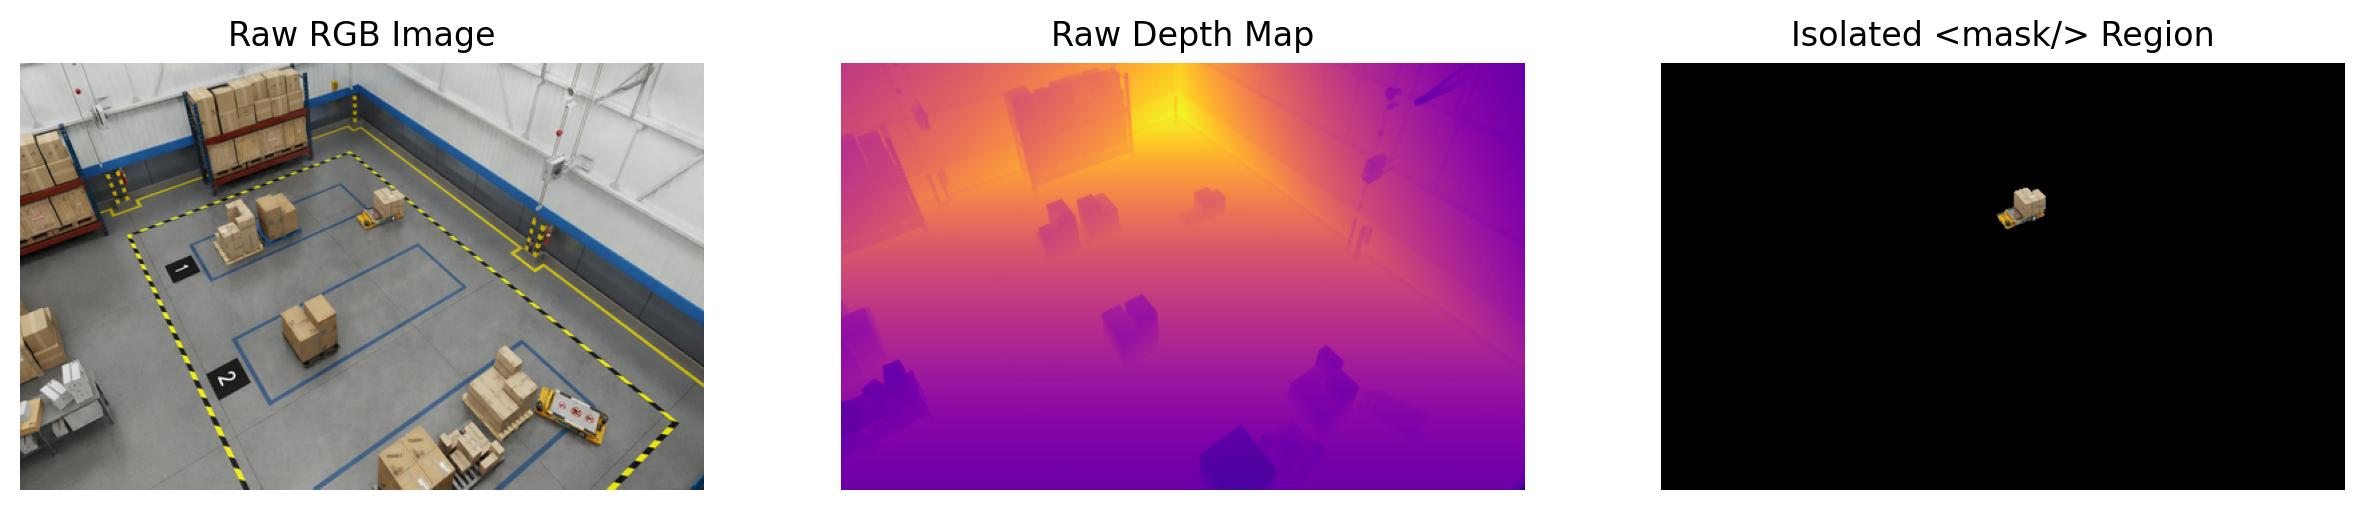

In [4]:
# Decode the RLE dictionary back into a Binary Region
binary_orig   = mask_utils.decode(rle_mask).astype(np.float32)  # [1080, 1920]
mask_pil      = Image.fromarray(binary_orig)
mask_resized  = mask_pil.resize((TARGET_W, TARGET_H), Image.NEAREST)
binary_mask   = np.array(mask_resized).astype(bool) 

fig, axes = plt.subplots(1, 3, figsize=(15, 6), dpi=200)

axes[0].imshow(rgb_np)
axes[0].set_title("Raw RGB Image")
axes[0].axis("off")

axes[1].imshow(depth_np, cmap='plasma')
axes[1].set_title("Raw Depth Map")
axes[1].axis("off")

# Isolate just the Masked Region
masked_rgb = rgb_np.copy()
masked_rgb[~binary_mask] = 0
axes[2].imshow(masked_rgb)
axes[2].set_title("Isolated <mask/> Region")
axes[2].axis("off")

plt.show()

In [5]:
# We create an untrained RTE just to use its feature extraction methods
rte = RTE().cuda()

# Grid properties based on 320p resolution
h_soft, w_soft = int(320 / 32), int(512 / 32)
binary_tensor, soft2d = rte._rle_to_soft_mask(rle_mask, h_soft, w_soft, device=torch.device('cuda'))

depth_tensor = depth_tensor.cuda()
rgb_tensor = rgb_tensor.cuda()

print("Soft Mask Target Grid Shape:", soft2d.shape)

Soft Mask Target Grid Shape: torch.Size([10, 16])


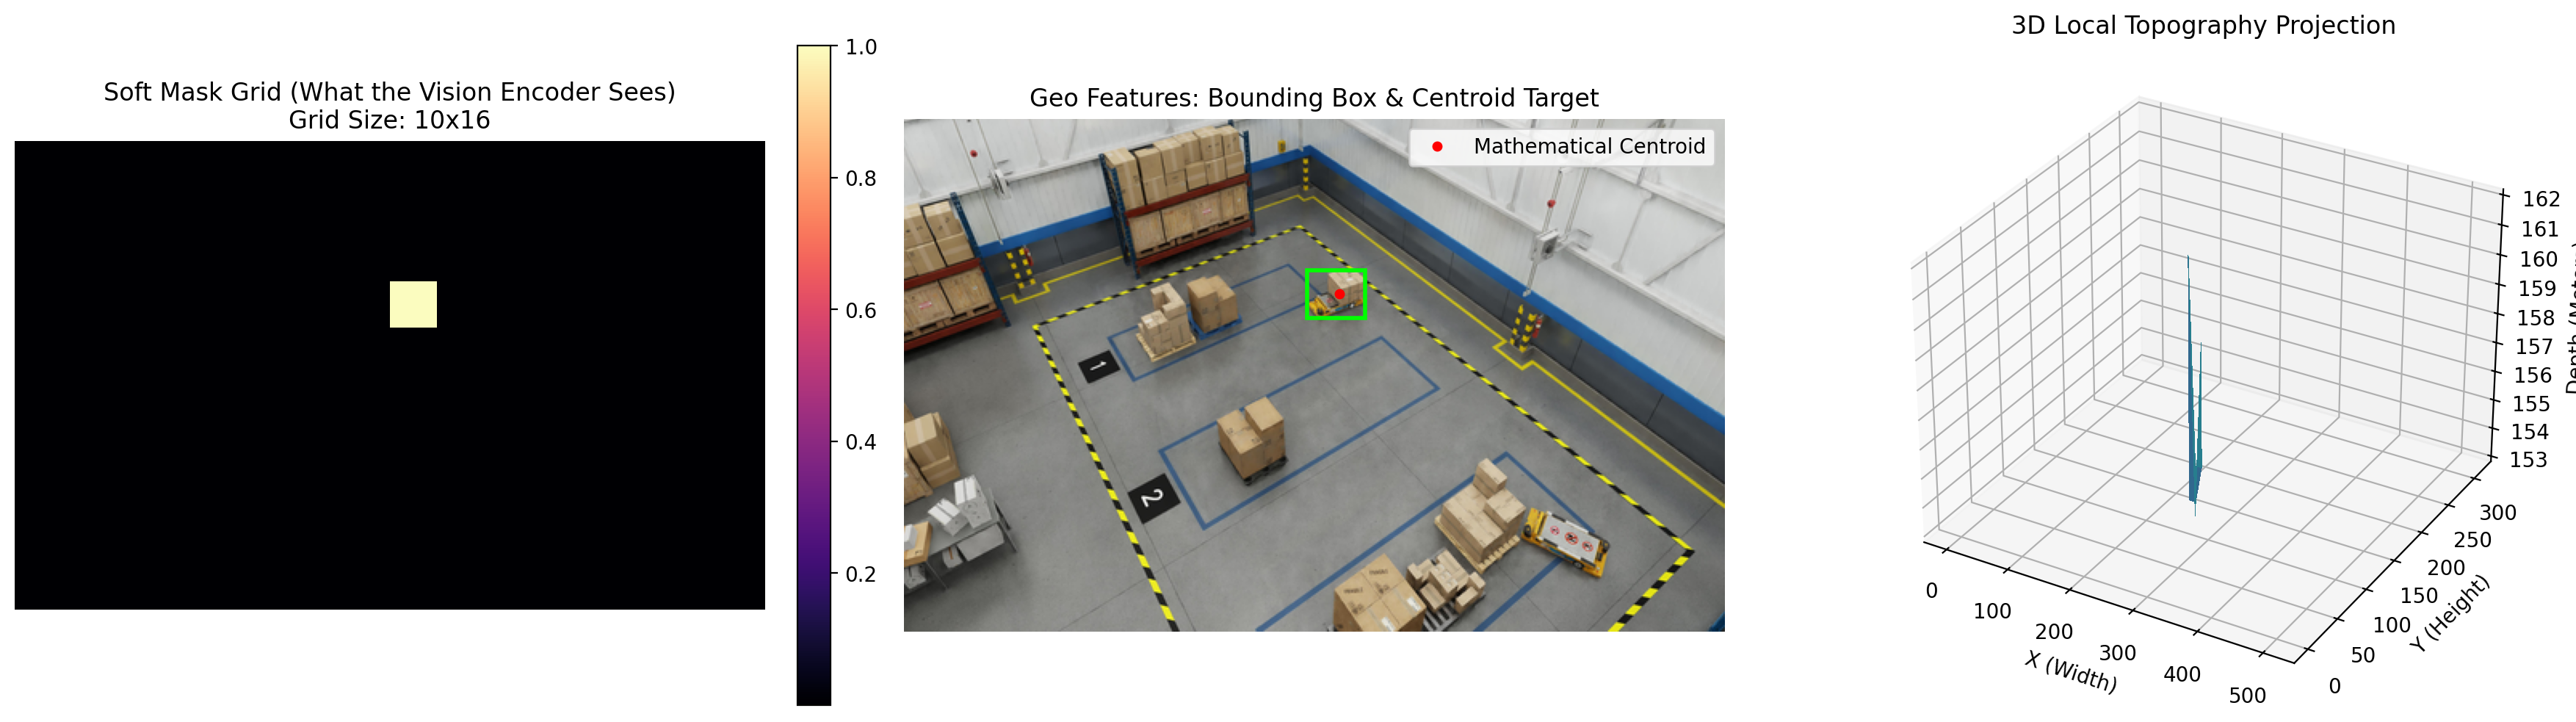

In [6]:
# Re-run geo features quickly just to get the bounding box math
# (Since we are putting this before cell 8)
H, W = depth_tensor.shape
depth_f = depth_tensor.cpu().numpy()

# Get the bounding box from the mask
y_indices, x_indices = np.where(binary_mask)
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

# Get soft mask for Heatmap
h_soft, w_soft = int(320 / 32), int(512 / 32)
_, soft2d = rte._rle_to_soft_mask(rle_mask, h_soft, w_soft)
soft_heatmap = soft2d.cpu().numpy()

# Get centroid math
centroid_x = x_indices.mean()
centroid_y = y_indices.mean()


fig = plt.figure(figsize=(18, 5), dpi=200)

# --- PLOT 1: The Soft Mask Heatmap ---
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(soft_heatmap, cmap='magma')
ax1.set_title(f"Soft Mask Grid (What the Vision Encoder Sees)\nGrid Size: {h_soft}x{w_soft}")
ax1.axis("off")
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)


# --- PLOT 2: Bounding Box & Centroid Tracker ---
ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(rgb_np)
# Draw the bounding box
rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                         linewidth=2, edgecolor='lime', facecolor='none')
ax2.add_patch(rect)
# Draw the centroid
ax2.plot(centroid_x, centroid_y, 'ro', markersize=4, label="Mathematical Centroid")
ax2.set_title("Geo Features: Bounding Box & Centroid Target")
ax2.legend()
ax2.axis("off")


# --- PLOT 3: 3D Depth Surface Projection ---
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Downsample the depth mask just so the 3D plot doesn't crash from too many points
step = 10
X, Y = np.meshgrid(np.arange(0, W, step), np.arange(0, H, step))
Z = depth_f[::step, ::step]
Mask_3D = binary_mask[::step, ::step]

# Only plot the Z values that actually exist inside object's mask
Z_masked = np.where(Mask_3D, Z, np.nan)

ax3.plot_surface(X, Y, Z_masked, cmap='viridis', linewidth=0, antialiased=False)
ax3.set_title("3D Local Topography Projection")
ax3.set_xlabel("X (Width)")
ax3.set_ylabel("Y (Height)")
ax3.set_zlabel("Depth (Meters)")
ax3.view_init(elev=30, azim=-60)  # Tilt the 3D camera

plt.tight_layout()
plt.show()


In [7]:
# 1. Manually create the missing Gray Image tensor
gray_tensor = rgb_tensor.mean(dim=0)  # [H, W]

# 2. Convert binary_mask (numpy) to boolean Torch Tensor
mask_t = torch.from_numpy(binary_mask).bool()

# 3. Call with all 3 arguments
rgb_feats = rte._rgb_features(rgb_tensor, gray_tensor, mask_t)

print("RGB FEATURES (12-dim):")
print("-----------------------")
print(f"R Mean: {rgb_feats[0]:.4f} | G Mean: {rgb_feats[1]:.4f} | B Mean: {rgb_feats[2]:.4f}")
print(f"R Std : {rgb_feats[3]:.4f} | G Std : {rgb_feats[4]:.4f} | B Std : {rgb_feats[5]:.4f}")
print(f"Luminance -> Mean: {rgb_feats[6]:.4f}, Std: {rgb_feats[7]:.4f}, Min: {rgb_feats[8]:.4f}, Max: {rgb_feats[9]:.4f}")
print(f"Contrast: {rgb_feats[10]:.4f} | Saturation: {rgb_feats[11]:.4f}")


RGB FEATURES (12-dim):
-----------------------
R Mean: 0.5884 | G Mean: 0.5121 | B Mean: 0.3766
R Std : 0.1703 | G Std : 0.1532 | B Std : 0.1666
Luminance -> Mean: 0.4923, Std: 0.1480, Min: 0.1176, Max: 0.8771
Contrast: 0.0876 | Saturation: 0.3600


DEPTH FEATURES (28-dim):
-------------------------
Mean Depth : 156.86 (raw pixel intensity)
Std Dev    : 4.00 (raw pixel variation)
Centroid   : (x=0.50, y=0.30) [Soft Grid Coords]


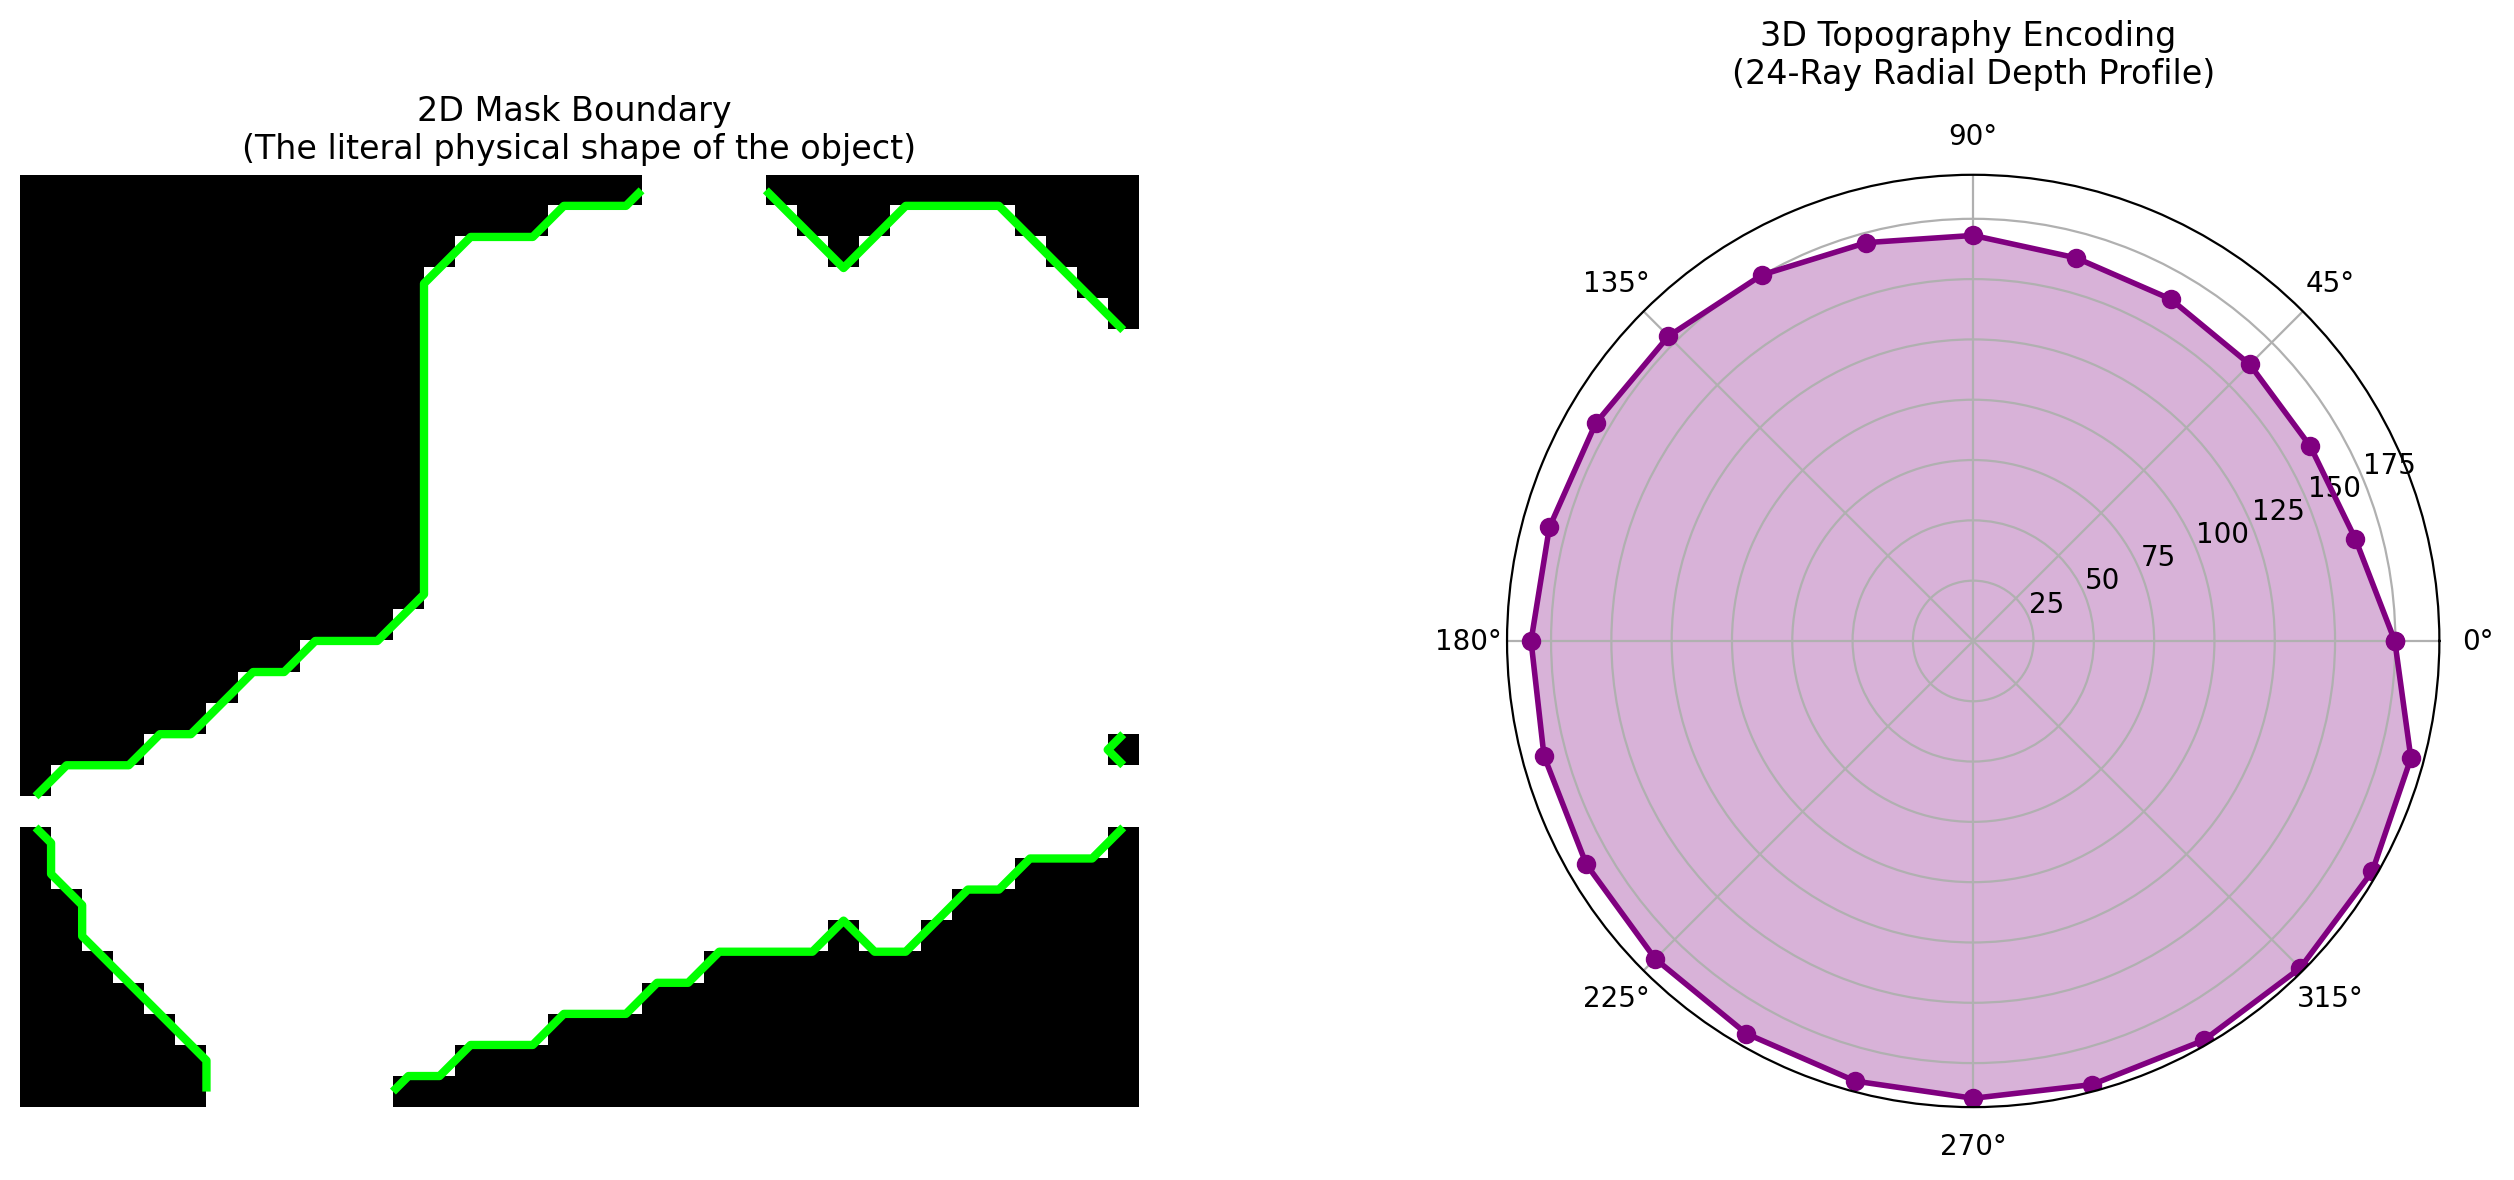

In [8]:
# Extract the depth features
depth_feats = rte._depth_features(depth_tensor.unsqueeze(0), binary_mask, soft2d.cuda(), h_soft, w_soft)

mean_d = depth_feats[0].item()
std_d = depth_feats[1].item()
cx, cy = depth_feats[2].item(), depth_feats[3].item()
rays = depth_feats[4:28].cpu().numpy()

print("DEPTH FEATURES (28-dim):")
print("-------------------------")
print(f"Mean Depth : {mean_d:.2f} (raw pixel intensity)")
print(f"Std Dev    : {std_d:.2f} (raw pixel variation)")
print(f"Centroid   : (x={cx:.2f}, y={cy:.2f}) [Soft Grid Coords]")

# Set up a 1x2 side-by-side plot
fig = plt.figure(figsize=(14, 6), dpi=200)

# --- PLOT 1: The 2D Shape/Boundary contour of the mask ---
ax1 = fig.add_subplot(1, 2, 1)

# Isolate just the bounding box of the mask so it isn't tiny
y_indices, x_indices = np.where(binary_mask)
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()
cropped_mask = binary_mask[y_min:y_max, x_min:x_max]

ax1.imshow(cropped_mask, cmap='bone')
ax1.contour(cropped_mask, levels=[0.5], colors='lime', linewidths=3)
ax1.set_title("2D Mask Boundary \n(The literal physical shape of the object)")
ax1.axis("off")


# --- PLOT 2: The 24 Radial Depth Rays ---
angles = np.linspace(0, 2 * np.pi, 24, endpoint=False)
ax2 = fig.add_subplot(1, 2, 2, projection='polar')

# Wrap the polar plot back to the start point
ax2.plot(np.append(angles, angles[0]), np.append(rays, rays[0]), '-o', color='purple', linewidth=2)
ax2.fill(np.append(angles, angles[0]), np.append(rays, rays[0]), alpha=0.3, color='purple')

ax2.set_title("3D Topography Encoding \n(24-Ray Radial Depth Profile)", y=1.08)

plt.tight_layout()
plt.show()


GEO FEATURES (16-dim Tensor):
-----------------------
  global_mean_d       : 113.2129
  global_std_d        : 44.7787
  relative_depth      : 1.3855
  depth_percentile    : 0.8129
  area_ratio          : 0.0042
  centroid_x          : 0.5308
  centroid_y          : 0.3410
  bbox_x0             : 0.4912
  bbox_y0             : 0.2947
  bbox_w              : 0.0705
  bbox_h              : 0.0940
  min_depth_norm      : 0.5866
  max_depth_norm      : 0.7047
  aspect_ratio        : 0.7491
  dist_to_center      : 0.1619
  depth_range_norm    : 0.1181


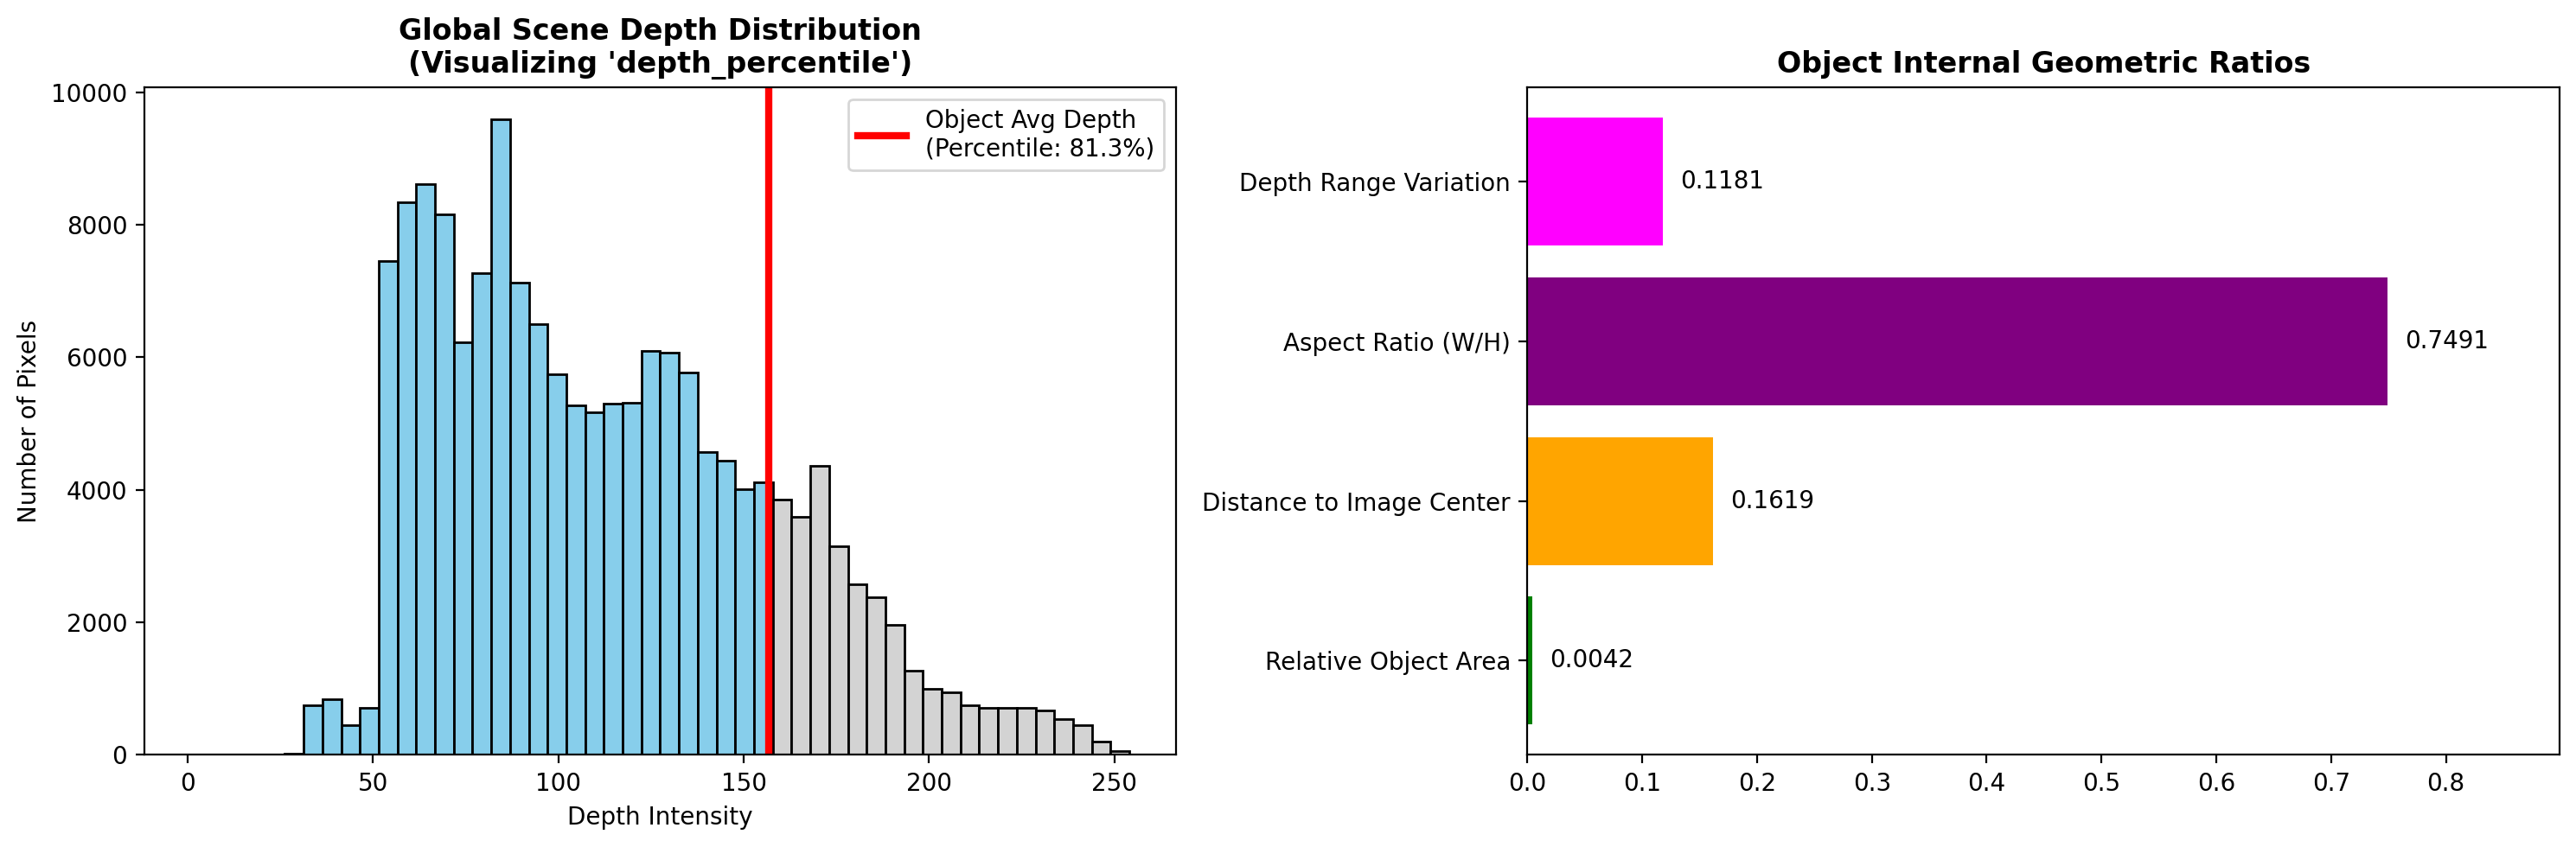

In [ ]:
# Evaluate the Geo Features

dev = next(rte.parameters()).device

# 1. Sync the primary tensors to the exact same device
depth_tensor = depth_tensor.to(dev)
mask_t = torch.from_numpy(binary_mask).bool().to(dev)

# 2. Compute the 3 global scene statistics 
global_mean = depth_tensor.mean()
global_std  = depth_tensor.std()
global_max  = depth_tensor.max()

# 3. Feed all 5 arguments into the optimized function
geo_feats = rte._geo_features(depth_tensor, mask_t, global_mean, global_std, global_max)

geo_names = [
    "global_mean_d", "global_std_d", "relative_depth", "depth_percentile",
    "area_ratio", "centroid_x", "centroid_y", "bbox_x0", "bbox_y0", 
    "bbox_w", "bbox_h", "min_depth_norm", "max_depth_norm", 
    "aspect_ratio", "dist_to_center", "depth_range_norm"
]

print("GEO FEATURES (16-dim Tensor):")
print("-----------------------")
for name, val in zip(geo_names, geo_feats.tolist()):
    print(f"  {name:20s}: {val:.4f}")

# --- DASHBOARD VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=200)

# 1. Global Depth Histogram (Visualizing Depth Percentile)
global_depths = depth_tensor.cpu().numpy().flatten()

# We use 50 bins to show the distribution of depths in the room
counts, bins, patches = ax1.hist(global_depths, bins=50, color='lightgray', edgecolor='black')

# Find where the object sits in the room
obj_mean_depth = geo_feats[0].item() * geo_feats[2].item() # global_mean * relative_depth
ax1.axvline(obj_mean_depth, color='red', linewidth=3, label=f"Object Avg Depth\n(Percentile: {geo_feats[3].item():.1%})")

# Highlight the "Percentile" area (pixels shallower than object)
for count, bin_edge, patch in zip(counts, bins, patches):
    if bin_edge < obj_mean_depth:
        patch.set_facecolor('skyblue')

ax1.set_title("Global Scene Depth Distribution\n(Visualizing 'depth_percentile')", fontweight='bold')
ax1.set_xlabel("Depth Intensity")
ax1.set_ylabel("Number of Pixels")
ax1.legend()


# 2. Key Geometric Ratios Dashboard
labels = ['Relative Object Area', 'Distance to Image Center', 'Aspect Ratio (W/H)', 'Depth Range Variation']
values = [
    geo_feats[4].item(),  # area_ratio
    geo_feats[14].item(), # dist_to_center
    geo_feats[13].item(), # aspect_ratio
    geo_feats[15].item()  # depth_range_norm
]

colors = ['green', 'orange', 'purple', 'magenta']
ax2.barh(labels, values, color=colors)
ax2.set_xlim(0, max(values) * 1.2)  # Give bars some breathing room
ax2.set_title("Object Internal Geometric Ratios", fontweight='bold')

for index, value in enumerate(values):
    ax2.text(value + (max(values) * 0.02), index, f'{value:.4f}', va='center')

plt.tight_layout()
plt.show()